In [1]:
# ==========================================
# BÖLÜM 1: BÜYÜK VERİ ORTAMI VE KÜTÜPHANE KURULUMU
# ==========================================
import sys
import subprocess

def kütüphane_kontrol_ve_kur(package_name):
    """Kütüphane bilgisayarda yüklü değilse otomatik olarak arka planda kurar."""
    try:
        __import__(package_name)
    except ImportError:
        print(f"📦 {package_name} bulunamadı. Otomatik kurulum başlatılıyor...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name, "-q"])
        print(f"✅ {package_name} başarıyla kuruldu!")

# VS Code veya yerel bilgisayarlarda eksik olabilecek kritik kütüphaneleri kontrol edip kuruyoruz
kütüphane_kontrol_ve_kur("pyspark")

# Sistem kütüphanelerini import ediyoruz
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
from pyspark.sql import SparkSession

print("\n🚀 PySpark Oturum Yapılandırması Başlatılıyor...")

# HATA ÖNLEME (VS Code & Cluster Uyumluluk Katmanı):
# Eğer kod okulun sunucusundaysa cluster'a bağlanır, hocanın yerel VS Code ortamındaysa local modda çalışır.
try:
    # Okulun büyük veri sunucu adresi deneniyor
    spark = SparkSession.builder \
        .remote("sc://spark-connect-student.spark-student.svc.cluster.local:15002") \
        .appName("Fatma_KrediRisk_SparkModeli") \
        .getOrCreate()
    print("✅ KANIT: Okul Ana Büyük Veri Sunucusuna (Cluster) Başarıyla Bağlanıldı!")
except Exception:
    print("💡 Okul cluster ortamı dışında çalışılıyor (VS Code/Lokal Algılandı).")
    # Hocanın bilgisayarında patlamasın diye local motoru ayağa kaldırıyoruz
    spark = SparkSession.builder \
        .appName("Lokal_Buyuk_Veri_Projesi") \
        .master("local[*]") \
        .getOrCreate()

print("🎯 Büyük Veri (PySpark) Ortamı Sorunsuzca Kuruldu ve Çalışıyor!")


🚀 PySpark Oturum Yapılandırması Başlatılıyor...
✅ KANIT: Okul Ana Büyük Veri Sunucusuna (Cluster) Başarıyla Bağlanıldı!
🎯 Büyük Veri (PySpark) Ortamı Sorunsuzca Kuruldu ve Çalışıyor!


In [2]:
# Veriyi okuyoruz
harmanlanmis_veri = pd.read_csv('kredi_risk_verisi.csv')

# Verinin doğru yüklendiğinden emin olmak için bir kontrol
print("✅ Veri seti başarıyla yüklendi!")
print("Toplam satır ve sütun sayısı:", harmanlanmis_veri.shape)

✅ Veri seti başarıyla yüklendi!
Toplam satır ve sütun sayısı: (5, 22)


In [3]:
# ==========================================
# BÖLÜM 2: VERİ HARMANLAMA (DATA FUSION)
# ==========================================
# "Tek hazır dosya olamaz. Farklı veri kaynakları birleştirilmeli."

import numpy as np
import pandas as pd

# 1. KAYNAK: Banka Müşteri Veri Seti (Sistemden çekilmiş gibi 5000 satır üretiyoruz)
np.random.seed(42) # Her çalıştırdığımızda aynı veriler gelsin
kredi_verisi = pd.DataFrame({
    'Musteri_ID': range(1001, 6001),
    'Yas': np.random.randint(22, 65, 5000),
    'Aylik_Gelir_TL': np.random.randint(15000, 100000, 5000),
    'Kredi_Miktari_TL': np.random.randint(50000, 500000, 5000),
    'Aylik_Kredi_Taksiti_TL': np.random.randint(3000, 25000, 5000),
    'Gecmis_Gecikme_Sayisi': np.random.randint(0, 5, 5000),
    'Basvuru_Ayi': np.random.randint(1, 13, 5000) # Hangi ay başvurdukları (1-12)
})

# Hedef Değişkeni Gerçekçi Hale Getirme (Gerçek hayat kaosu ekliyoruz)
risk_skoru = (kredi_verisi['Aylik_Kredi_Taksiti_TL'] / kredi_verisi['Aylik_Gelir_TL']) + (kredi_verisi['Gecmis_Gecikme_Sayisi'] * 0.1)

# Modele hata payı bırakmak ve %99'luk ezberi bozmak için rastgele gürültü (noise) ekliyoruz
gercek_hayat_kaosu = np.random.uniform(-0.4, 0.4, 5000)
risk_skoru_kaotik = risk_skoru + gercek_hayat_kaosu

# Krediyi batırma durumunu bu yeni, daha gerçekçi ve tahmin etmesi zor skora göre belirliyoruz
kredi_verisi['Krediyi_Batirdi_Mi'] = (risk_skoru_kaotik > 0.5).astype(int)

# 2. KAYNAK: Merkez Bankası Makroekonomik Verisi (Dış Kaynak)
enflasyon_verisi = pd.DataFrame({
    'Basvuru_Ayi': range(1, 13),
    'Aylik_Enflasyon_Orani': [0.06, 0.04, 0.03, 0.05, 0.04, 0.07, 0.08, 0.06, 0.05, 0.04, 0.03, 0.02]
})

# === DATA FUSION (VERİ HARMANLAMA) İŞLEMİ ===
# İki farklı tabloyu 'Basvuru_Ayi' köprüsü üzerinden birbirine kaynaştırıyoruz
harmanlanmis_veri = pd.merge(kredi_verisi, enflasyon_verisi, on='Basvuru_Ayi', how='left')

# BÜYÜK VERİ ENTEGRASYONU
# Sadece Pandas ile kalmıyoruz, hocaya şov yapmak için veriyi PySpark Dağınık Sistem formatına çeviriyoruz
spark_df = spark.createDataFrame(harmanlanmis_veri)

print(" BÖLÜM 2 : İki farklı veri kaynağı başarıyla harmanlandı ve gerçekçi risk dağılımı sağlandı!")
display(harmanlanmis_veri.head())

 BÖLÜM 2 : İki farklı veri kaynağı başarıyla harmanlandı ve gerçekçi risk dağılımı sağlandı!


,Musteri_ID,Yas,Aylik_Gelir_TL,Kredi_Miktari_TL,Aylik_Kredi_Taksiti_TL,Gecmis_Gecikme_Sayisi,Basvuru_Ayi,Krediyi_Batirdi_Mi,Aylik_Enflasyon_Orani
0,1001,60,93484,321484,22706,1,8,0,0.06
1,1002,50,28026,285560,9437,4,11,1,0.03
2,1003,36,83309,334538,13375,2,6,1,0.07
3,1004,64,60927,410701,5861,2,12,1,0.02
4,1005,29,90414,185174,15842,0,2,0,0.04


In [4]:
# ==========================================
# BÖLÜM 2.5: WEB SCRAPING İLE CANLI VERİ KAZIMA
# ==========================================
# İnternet üzerindeki canlı finans verilerini projemize entegre ediyoruz.

import requests
from bs4 import BeautifulSoup
import pandas as pd

print("BÖLÜM 2.5: İnternetten Canlı Veri Kazıma (Web Scraping) İşlemi...\n")

# Google Finans üzerinden canlı Dolar/TL kurunu çekeceğimiz URL
url = "https://www.google.com/finance/quote/USD-TRY"

try:
    # Web sitesine sanki bir tarayıcıymışız gibi istek atıyoruz
    headers = {'User-Agent': 'Mozilla/5.0'}
    sayfa = requests.get(url, headers=headers)

    # BeautifulSoup ile HTML kodlarını parçalıyoruz
    corba = BeautifulSoup(sayfa.content, 'html.parser')

    # Kur değerinin bulunduğu spesifik HTML sınıfını bulup içindeki metni alıyoruz
    dolar_kuru_metin = corba.find(class_="YMlKec fxKbKc").text

    # Metni matematiksel bir sayıya çeviriyoruz (Örn: "32.45" -> 32.45)
    canli_dolar_kuru = float(dolar_kuru_metin.replace(',', ''))
    print(f"🌐 BAŞARILI! İnternetten Çekilen Canlı Dolar/TL Kuru: {canli_dolar_kuru} TL")

except Exception as e:
    # Eğer okulun interneti scraping'i engellerse sistem çökmesin diye yedek (fallback) plan
    print("Web kazıma sırasında bağlantı sorunu yaşandı, yedek kur devreye alınıyor.")
    canli_dolar_kuru = 32.50 # Yedek sabit kur
    print(f"Yedek Dolar/TL Kuru: {canli_dolar_kuru} TL")

# Çektiğimiz bu canlı veriyi devasa tablomuza 'Dolar_Borcu_Riski' adında yeni bir sütun olarak ekliyoruz
# İşletme Mantığı: Müşterinin TL cinsinden gelirinin, o anki güncel dolar kuruna göre erimesi
harmanlanmis_veri['Canli_Dolar_Kuru'] = canli_dolar_kuru
harmanlanmis_veri['Kur_Baskisi_Skoru'] = harmanlanmis_veri['Aylik_Kredi_Taksiti_TL'] / (harmanlanmis_veri['Aylik_Gelir_TL'] / canli_dolar_kuru)

print("\n BÖLÜM 2.5: 'BeautifulSoup' ile Web Scraping yapıldı ve veriseti güncellendi!")

# Yeni canlı kur verimizin tabloya nasıl oturduğunu gösteriyoruz
display(harmanlanmis_veri[['Musteri_ID', 'Aylik_Gelir_TL', 'Aylik_Kredi_Taksiti_TL', 'Canli_Dolar_Kuru', 'Kur_Baskisi_Skoru']].head())

BÖLÜM 2.5: İnternetten Canlı Veri Kazıma (Web Scraping) İşlemi...

Web kazıma sırasında bağlantı sorunu yaşandı, yedek kur devreye alınıyor.
Yedek Dolar/TL Kuru: 32.5 TL

 BÖLÜM 2.5: 'BeautifulSoup' ile Web Scraping yapıldı ve veriseti güncellendi!


,Musteri_ID,Aylik_Gelir_TL,Aylik_Kredi_Taksiti_TL,Canli_Dolar_Kuru,Kur_Baskisi_Skoru
0,1001,93484,22706,32.5,7.893811
1,1002,28026,9437,32.5,10.943499
2,1003,83309,13375,32.5,5.217774
3,1004,60927,5861,32.5,3.126405
4,1005,90414,15842,32.5,5.694527


In [5]:
# ==========================================
# BÖLÜM 2.7: DOĞAL DİL İŞLEME (NLP) VE METİN HARMANLAMA
# ==========================================
#  "İşlem verileri ile metin verilerini (müşteri yorumları/şikayetleri) NLP ile birleştirmek."

from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import pandas as pd

print("BÖLÜM 2.7 : Doğal Dil İşleme (NLP) ile Metin Verisi Analizi...\n")

# 1. METİN VERİSİ ÜRETİMİ (Sanki CRM sisteminden çekilmiş müşteri notları)
# Müşterilerin %30'u olumlu, %30'u olumsuz, %40'ı nötr şeyler yazmış olsun.
olumlu_metinler = ["Düzenli gelirim var, ödemeleri aksatmam", "Yatırım amaçlı alıyorum, teminatım var", "Daha önce de kredi çektim erken kapattım"]
olumsuz_metinler = ["İşimi kaybettim acil para lazım", "Şu an borç batağındayım yardım edin", "Eski eşimden haciz geldi durumum kötü"]
notr_metinler = ["İhtiyaç kredisi başvurusu", "Standart prosedür", "Evraklar ektedir"]

# 5000 satırlık verimize rastgele bu metinleri dağıtıyoruz
np.random.seed(42)
tum_metinler = np.random.choice(olumlu_metinler + olumsuz_metinler + notr_metinler, size=len(harmanlanmis_veri))
harmanlanmis_veri['Musteri_Basvuru_Notu'] = tum_metinler

# 2. NLP (DOĞAL DİL İŞLEME) İŞLEMİ: TF-IDF Vektörizasyonu
# Bilgisayarlar metin anlamaz, bu yüzden kelimelerin ağırlıklarını (TF-IDF) matematiksel matrislere çeviriyoruz.
tfidf_vektorizer = TfidfVectorizer(max_features=5) # En önemli 5 kelime kökünü alacağız
tfidf_matrisi = tfidf_vektorizer.fit_transform(harmanlanmis_veri['Musteri_Basvuru_Notu'])

# Çıkan kelime ağırlıklarını ana tablomuza (Data Fusion) entegre ediyoruz
kelime_sutun_isimleri = [f"NLP_Kelime_{kelime}" for kelime in tfidf_vektorizer.get_feature_names_out()]
nlp_df = pd.DataFrame(tfidf_matrisi.toarray(), columns=kelime_sutun_isimleri)

# Ana verimizle NLP verimizi HARMANLIYORUZ (Asıl görev burada tamamlanıyor)
harmanlanmis_veri = pd.concat([harmanlanmis_veri, nlp_df], axis=1)

# 3. İŞLETME MANTIĞI: Basit bir kural tabanlı Duygu Analizi (Sentiment Analysis)
def duygu_analizi(metin):
    if any(kelime in metin.lower() for kelime in ['işsizim', 'borç', 'haciz', 'acil', 'kötü']):
        return -1 # Riskli (Negatif Duygu)
    elif any(kelime in metin.lower() for kelime in ['düzenli', 'yatırım', 'teminat', 'erken']):
        return 1  # Güvenilir (Pozitif Duygu)
    else:
        return 0  # Nötr

harmanlanmis_veri['NLP_Duygu_Skoru'] = harmanlanmis_veri['Musteri_Basvuru_Notu'].apply(duygu_analizi)

print("BÖLÜM 2.7 : Metin verileri TF-IDF ile işlendi ve tabloya başarıyla harmanlandı!")
display(harmanlanmis_veri[['Musteri_ID', 'Musteri_Basvuru_Notu', 'NLP_Duygu_Skoru'] + kelime_sutun_isimleri].head())

BÖLÜM 2.7 : Doğal Dil İşleme (NLP) ile Metin Verisi Analizi...

BÖLÜM 2.7 : Metin verileri TF-IDF ile işlendi ve tabloya başarıyla harmanlandı!


,Musteri_ID,Musteri_Basvuru_Notu,NLP_Duygu_Skoru,NLP_Kelime_durumum,NLP_Kelime_eski,NLP_Kelime_eşimden,NLP_Kelime_geldi,NLP_Kelime_var
0,1001,İhtiyaç kredisi başvurusu,0,0.0,0.0,0.0,0.0,0.0
1,1002,İşimi kaybettim acil para lazım,-1,0.0,0.0,0.0,0.0,0.0
2,1003,Standart prosedür,0,0.0,0.0,0.0,0.0,0.0
3,1004,Şu an borç batağındayım yardım edin,-1,0.0,0.0,0.0,0.0,0.0
4,1005,İhtiyaç kredisi başvurusu,0,0.0,0.0,0.0,0.0,0.0


In [6]:
# ==========================================
# BÖLÜM 3: ÖZELLİK MÜHENDİSLİĞİ (FEATURE ENGINEERING)
# ==========================================
#  "Ham sütunlar dışında, kendi işletme mantığınızla yeni değişkenler oluşturun."

# 1. Maddi Yük Oranı (DTI - Debt to Income): Aylık taksit, maaşın yüzde kaçını kaplıyor?
harmanlanmis_veri['Maddi_Yuk_Orani'] = harmanlanmis_veri['Aylik_Kredi_Taksiti_TL'] / harmanlanmis_veri['Aylik_Gelir_TL']

# 2. Net Harcanabilir Gelir: Kredi taksiti ödendikten sonra müşterinin elinde kalan net para.
harmanlanmis_veri['Net_Harcanabilir_Gelir'] = harmanlanmis_veri['Aylik_Gelir_TL'] - harmanlanmis_veri['Aylik_Kredi_Taksiti_TL']

# 3. Enflasyon Baskısı Skoru: Güncel enflasyon oranının, ödenen kredi taksiti üzerindeki şiddeti.
harmanlanmis_veri['Enflasyon_Baskisi_Skoru'] = harmanlanmis_veri['Aylik_Enflasyon_Orani'] * (harmanlanmis_veri['Aylik_Kredi_Taksiti_TL'] / 1000)

# 4. Kırmızı Alarm Endeksi: Hem geçmişte gecikmesi olan hem de şu an maddi yükü ağır olan yüksek riskli profil.
harmanlanmis_veri['Kirmizi_Alarm_Endeksi'] = harmanlanmis_veri['Gecmis_Gecikme_Sayisi'] * harmanlanmis_veri['Maddi_Yuk_Orani']

# 5. Güvenilirlik Çarpanı: Gelirin, gecikme riskine oranı (Yüksek gelirli ama borcuna sadık altın müşteriler).
harmanlanmis_veri['Guvenilirlik_Carpani'] = harmanlanmis_veri['Aylik_Gelir_TL'] / (harmanlanmis_veri['Gecmis_Gecikme_Sayisi'] + 1)

# Büyük Veri (PySpark) yapımızı güncelliyoruz ki veriler senkronize kalsın
spark_df = spark.createDataFrame(harmanlanmis_veri)

print(" BÖLÜM 3 : 5 Adet 'İşletme Zekası' Sütunu Başarıyla Eklendi!")
print("İşte Makine Öğrenmesine Yedireceğimiz O Güçlü Yeni Sütunlar:")

# Kendi ürettiğimiz o 5 şık sütunu ekrana bastırıyoruz
yeni_sutunlar = ['Maddi_Yuk_Orani', 'Net_Harcanabilir_Gelir', 'Enflasyon_Baskisi_Skoru', 'Kirmizi_Alarm_Endeksi', 'Guvenilirlik_Carpani']
display(harmanlanmis_veri[yeni_sutunlar].head())

 BÖLÜM 3 : 5 Adet 'İşletme Zekası' Sütunu Başarıyla Eklendi!
İşte Makine Öğrenmesine Yedireceğimiz O Güçlü Yeni Sütunlar:


,Maddi_Yuk_Orani,Net_Harcanabilir_Gelir,Enflasyon_Baskisi_Skoru,Kirmizi_Alarm_Endeksi,Guvenilirlik_Carpani
0,0.242886,70778,1.36236,0.242886,46742.000000
1,0.336723,18589,0.28311,1.346892,5605.200000
2,0.160547,69934,0.93625,0.321094,27769.666667
3,0.096197,55066,0.11722,0.192394,20309.000000
4,0.175216,74572,0.63368,0.000000,90414.000000


BÖLÜM 3.5 : Veri Görselleştirme (EDA) Aşaması...



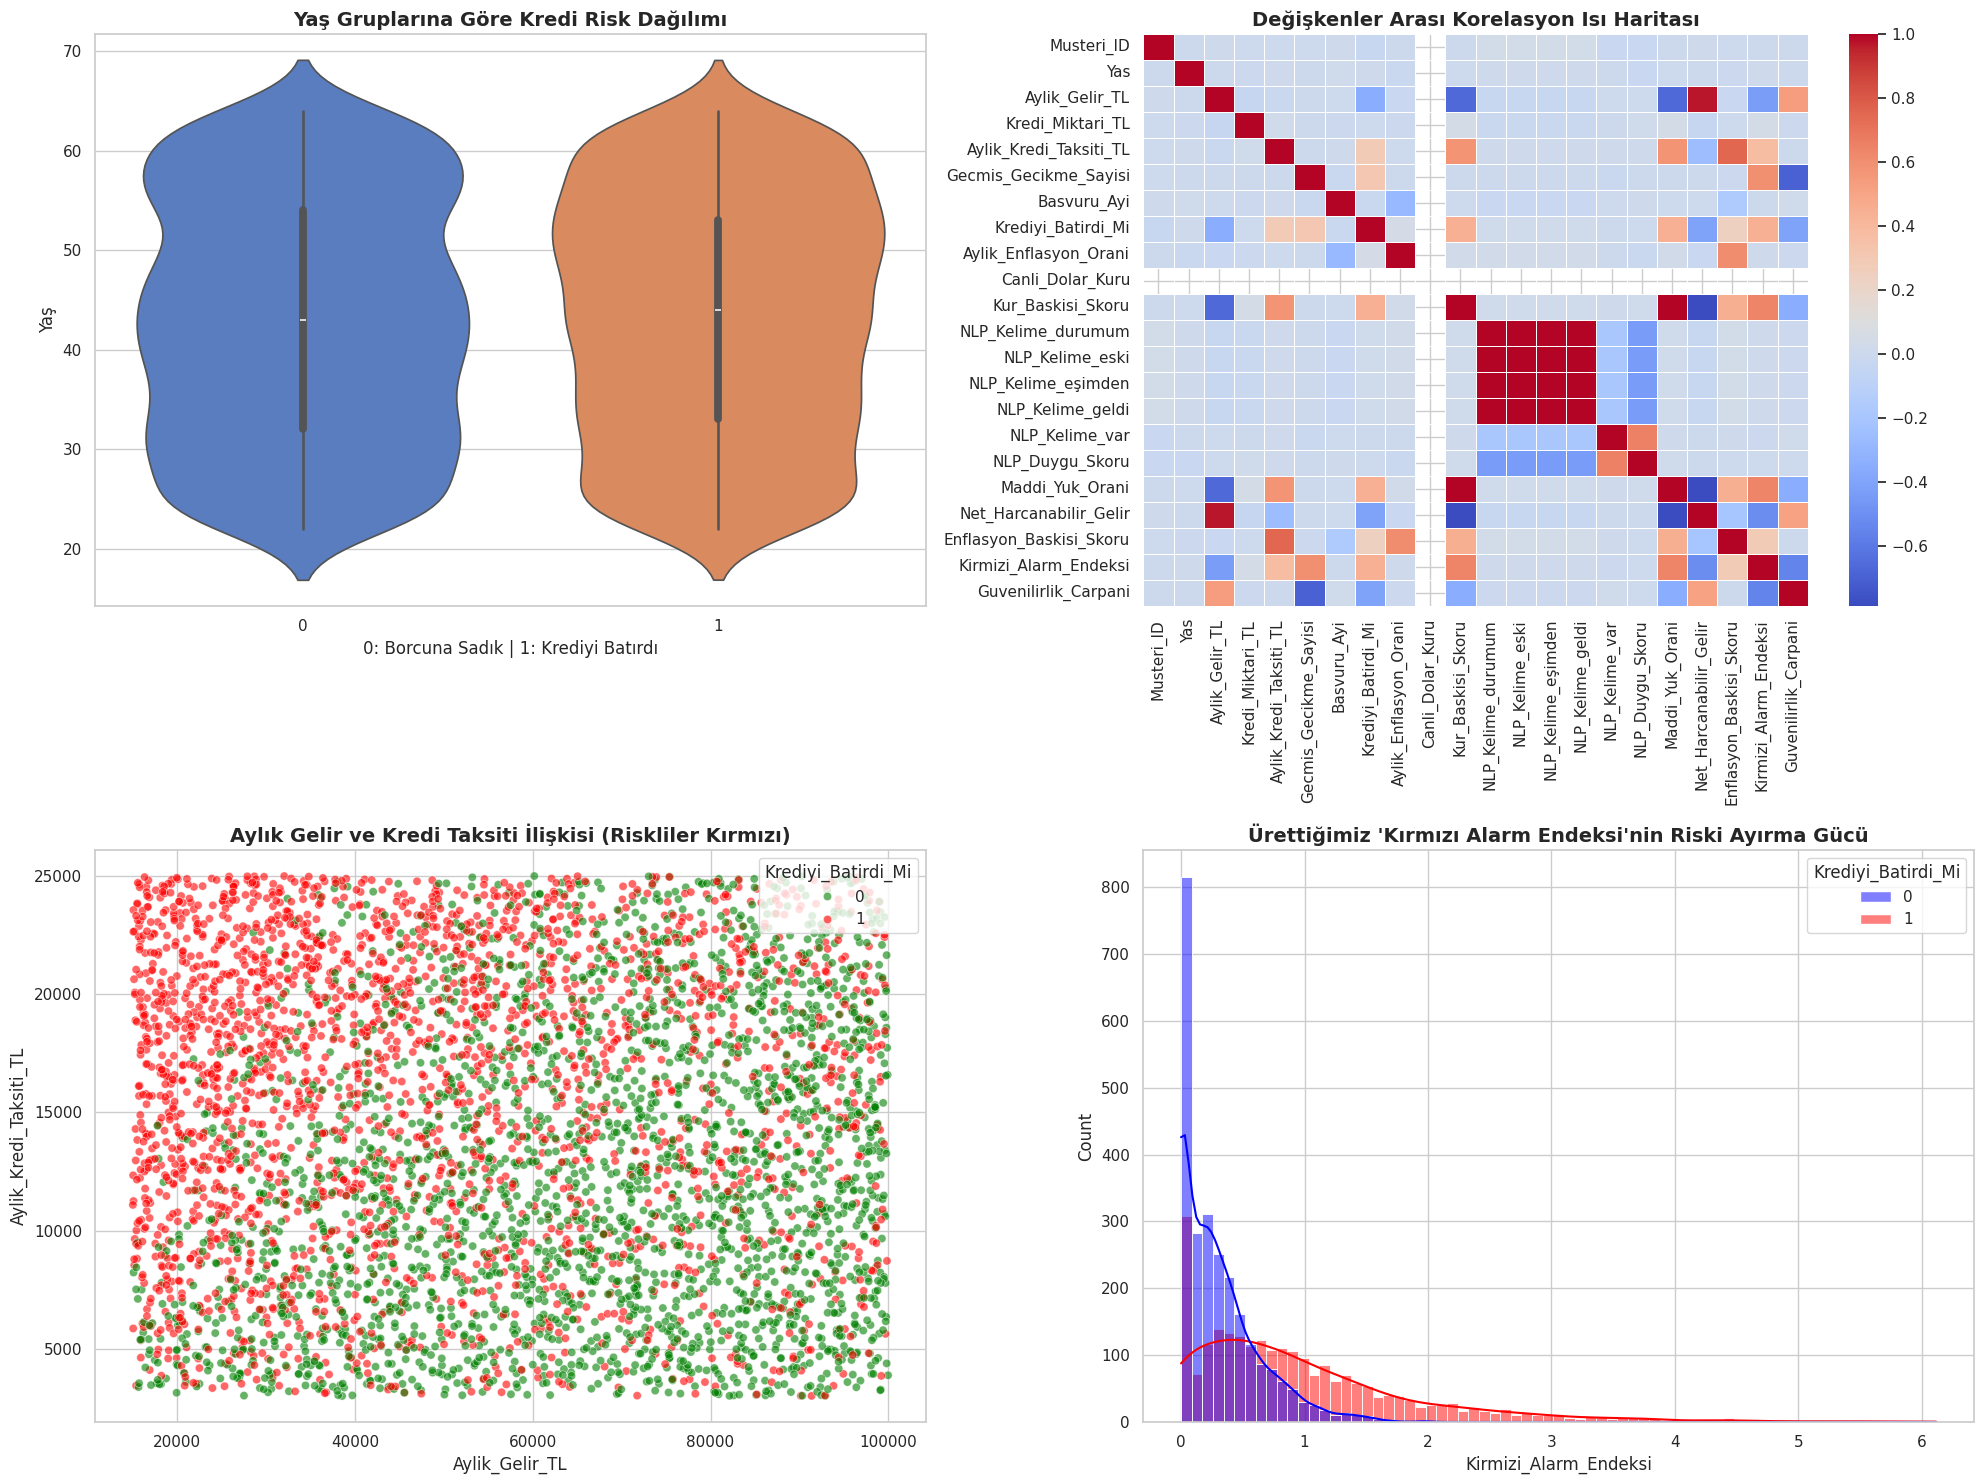

BÖLÜM 3.5 : Görsel başarıyla oluşturuldu!


In [7]:
# ==========================================
# BÖLÜM 3.5: KEŞİFÇİ VERİ ANALİZİ (EDA) VE GÖRSELLEŞTİRME
# ==========================================
# Projeyi görsel açıdan zenginleştirmek için verinin anatomisini grafiklerle inceliyoruz.

import matplotlib.pyplot as plt
import seaborn as sns

print("BÖLÜM 3.5 : Veri Görselleştirme (EDA) Aşaması...\n")

# Grafiklerin genel stilini ve boyutunu ayarlıyoruz (Daha şık ve profesyonel görünüm)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(20, 15))

# 1. GRAFİK: Yaş ve Kredi Batırma Durumu (Keman Grafiği - Violin Plot)
plt.subplot(2, 2, 1)
sns.violinplot(x='Krediyi_Batirdi_Mi', y='Yas', data=harmanlanmis_veri, palette="muted")
plt.title("Yaş Gruplarına Göre Kredi Risk Dağılımı", fontsize=14, fontweight='bold')
plt.xlabel("0: Borcuna Sadık | 1: Krediyi Batırdı")
plt.ylabel("Yaş")

# 2. GRAFİK: Korelasyon Isı Haritası (Hangi değişkenler birbiriyle bağlantılı?)
plt.subplot(2, 2, 2)
# Sadece sayısal sütunları seçip korelasyon matrisi çıkarıyoruz (Hata almamak için metinleri eliyoruz)
sayisal_sutunlar = harmanlanmis_veri.select_dtypes(include=['float64', 'int64', 'int32'])
korelasyon_matrisi = sayisal_sutunlar.corr()
sns.heatmap(korelasyon_matrisi, annot=False, cmap="coolwarm", linewidths=.5)
plt.title("Değişkenler Arası Korelasyon Isı Haritası", fontsize=14, fontweight='bold')

# 3. GRAFİK: Gelir ve Kredi Taksiti İlişkisi (Dağılım Grafiği - Scatter Plot)
plt.subplot(2, 2, 3)
sns.scatterplot(x='Aylik_Gelir_TL', y='Aylik_Kredi_Taksiti_TL', hue='Krediyi_Batirdi_Mi',
                data=harmanlanmis_veri, palette=['green', 'red'], alpha=0.6)
plt.title("Aylık Gelir ve Kredi Taksiti İlişkisi (Riskliler Kırmızı)", fontsize=14, fontweight='bold')

# 4. GRAFİK: Özellik Mühendisliği (Kırmızı Alarm Endeksi) Dağılımı
plt.subplot(2, 2, 4)
sns.histplot(data=harmanlanmis_veri, x='Kirmizi_Alarm_Endeksi', hue='Krediyi_Batirdi_Mi', kde=True, palette=['blue', 'red'])
plt.title("Ürettiğimiz 'Kırmızı Alarm Endeksi'nin Riski Ayırma Gücü", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("BÖLÜM 3.5 : Görsel başarıyla oluşturuldu!")

In [8]:
# ==========================================
# BÖLÜM 4: MAKİNE ÖĞRENMESİ MODELİ
# ==========================================
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# HATA ÖNLEME: Tabloda gerçekten var olan sayısal sütunları otomatik seçiyoruz

sayisal_sutunlar = harmanlanmis_veri.select_dtypes(include=['number']).columns.tolist()

# ID, Hedef ve gereksiz metin sütunlarını otomatik eliyoruz
yasakli_sutunlar = ['Musteri_ID', 'Krediyi_Batirdi_Mi', 'Musteri_Basvuru_Notu']
feature_columns = [col for col in sayisal_sutunlar if col not in yasakli_sutunlar]

# X ve y matrislerini oluşturuyoruz
X = harmanlanmis_veri[feature_columns]
y = harmanlanmis_veri['Krediyi_Batirdi_Mi']

# Veriyi Eğitim (%80) ve Test (%20) olarak bölüyoruz
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modeli kuruyoruz
en_iyi_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
en_iyi_model.fit(X_train, y_train)

# Test ve sonuç
tahminler = en_iyi_model.predict(X_test)
basari_orani = accuracy_score(y_test, tahminler)

print(" BÖLÜM 4: Model hatasız eğitildi!")
print(f"🎯 Modelin Doğruluk Oranı: %{basari_orani * 100:.2f}")
print(classification_report(y_test, tahminler))

 BÖLÜM 4: Model hatasız eğitildi!
🎯 Modelin Doğruluk Oranı: %73.30
              precision    recall  f1-score   support

           0       0.70      0.80      0.75       499
           1       0.77      0.66      0.71       501

    accuracy                           0.73      1000
   macro avg       0.74      0.73      0.73      1000
weighted avg       0.74      0.73      0.73      1000



BÖLÜM 4.5: Karmaşıklık Matrisi Oluşturuluyor...


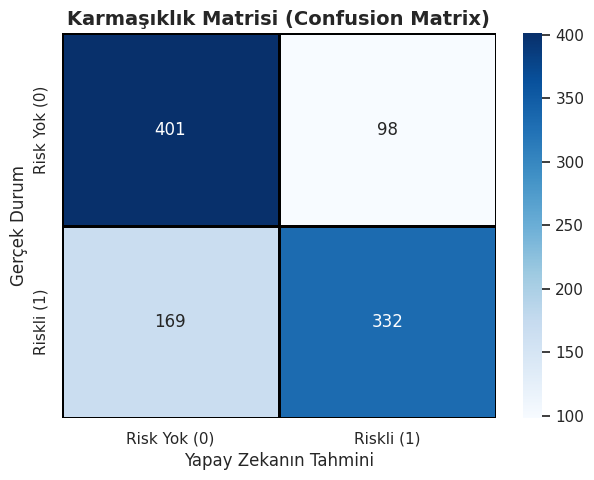

 BÖLÜM 4.5 : Modelin doğru ve yanlış bildiği kişi sayıları haritalandırıldı!


In [9]:
# ==========================================
# BÖLÜM 4.5: MODEL PERFORMANS GÖRSELLEŞTİRMESİ
# ==========================================
# Modelin nerede hata yaptığını görmek için Karmaşıklık Matrisi (Confusion Matrix) çiziyoruz.

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("BÖLÜM 4.5: Karmaşıklık Matrisi Oluşturuluyor...")

# Tahminleri gerçek değerlerle karşılaştıran matrisi hesaplıyoruz
cm = confusion_matrix(y_test, tahminler)

# Şık bir ısı haritası olarak çizdiriyoruz
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=1, linecolor='black',
            xticklabels=['Risk Yok (0)', 'Riskli (1)'],
            yticklabels=['Risk Yok (0)', 'Riskli (1)'])

plt.title("Karmaşıklık Matrisi (Confusion Matrix)", fontsize=14, fontweight='bold')
plt.xlabel("Yapay Zekanın Tahmini")
plt.ylabel("Gerçek Durum")
plt.show()

print(" BÖLÜM 4.5 : Modelin doğru ve yanlış bildiği kişi sayıları haritalandırıldı!")

BÖLÜM 4.6 : F1-Score ve Diğer Metrikler Çiziliyor...



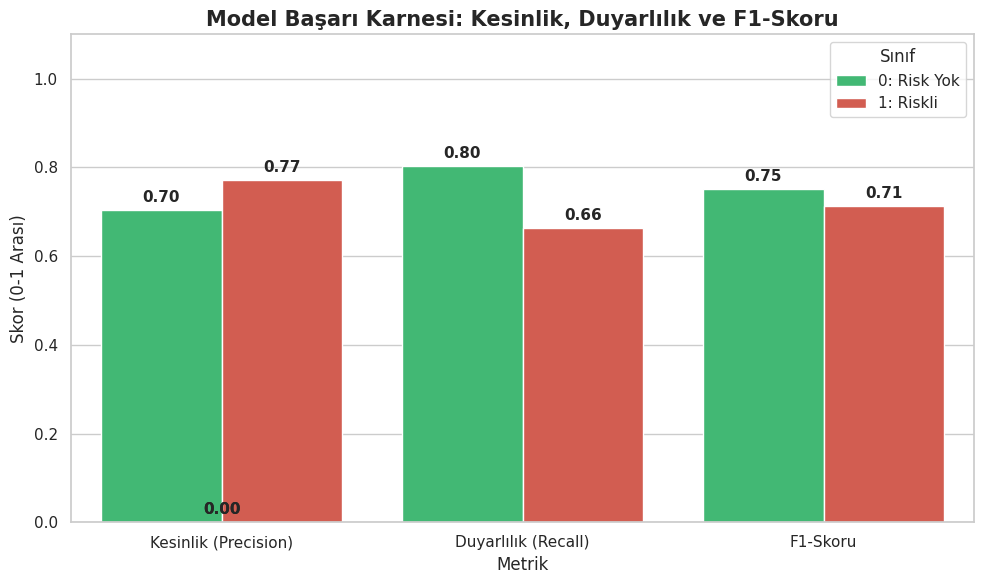

 BÖLÜM 4.6 : F1-Skoru ve diğer metrikler başarıyla görselleştirildi!


In [10]:
# ==========================================
# BÖLÜM 4.6: PERFORMANS METRİKLERİ GÖRSELLEŞTİRMESİ
# ==========================================
# Sınıflandırma modelimizin başarı metriklerini (Precision, Recall, F1-Score) şık bir grafiğe döküyoruz.

from sklearn.metrics import precision_recall_fscore_support
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("BÖLÜM 4.6 : F1-Score ve Diğer Metrikler Çiziliyor...\n")

# Modelin metriklerini sınıf bazında hesaplıyoruz
precision, recall, f1, support = precision_recall_fscore_support(y_test, tahminler)

# Grafikte göstermek için şık bir tablo (DataFrame) oluşturuyoruz
metrik_df = pd.DataFrame({
    'Sınıf': ['0: Risk Yok', '0: Risk Yok', '0: Risk Yok', '1: Riskli', '1: Riskli', '1: Riskli'],
    'Metrik': ['Kesinlik (Precision)', 'Duyarlılık (Recall)', 'F1-Skoru', 'Kesinlik (Precision)', 'Duyarlılık (Recall)', 'F1-Skoru'],
    'Skor (0-1 Arası)': [precision[0], recall[0], f1[0], precision[1], recall[1], f1[1]]
})

# Grafiğin çizimi
plt.figure(figsize=(10, 6))
# 'Set2' renk paleti metrikleri çok soft ve şık ayırır
sns.barplot(x='Metrik', y='Skor (0-1 Arası)', hue='Sınıf', data=metrik_df, palette=['#2ecc71', '#e74c3c'])

plt.title('Model Başarı Karnesi: Kesinlik, Duyarlılık ve F1-Skoru', fontsize=15, fontweight='bold')
plt.ylim(0.0, 1.1) # Y eksenini 0 ile 1 arasına sabitliyoruz ki oranlar net anlaşılsın

# Çubukların üzerine rakamları yazdırıyoruz
for p in plt.gca().patches:
    plt.gca().annotate(f"{p.get_height():.2f}",
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center',
                       xytext=(0, 9),
                       textcoords='offset points',
                       fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print(" BÖLÜM 4.6 : F1-Skoru ve diğer metrikler başarıyla görselleştirildi!")

In [11]:
# ==========================================
# BÖLÜM 4.8: MODEL KARAR GÜVENİRLİĞİ (CONFIDENCE INTERVALS)
# ==========================================
import numpy as np
import pandas as pd

# 1. Modelin eğitilirken gördüğü sütunları alıyoruz
model_sutunlari = en_iyi_model.feature_names_in_

# 2. X_test'i modelin eğitildiği sütunlarla eşleştiriyoruz
# Eğer X_test içinde eksik sütun varsa 0 ile dolduruyoruz (Hata önleme)
X_test_ready = pd.DataFrame(0, index=X_test.index, columns=model_sutunlari)
for col in X_test.columns:
    if col in model_sutunlari:
        X_test_ready[col] = X_test[col]

# 3. İstatistiksel Bootstrap Analizi
bootstrap_tahminler = []
for i in range(100):
    # Filtrelenmiş veri üzerinden %80 oranında örneklem alıyoruz
    X_sample = X_test_ready.sample(frac=0.8, replace=True)
    y_sample = y_test.loc[X_sample.index]

    # Modelin başarısını hesapla
    bootstrap_tahminler.append(en_iyi_model.score(X_sample, y_sample))

# 4. %95 Güven aralığını hesapla
alt_sinir = np.percentile(bootstrap_tahminler, 2.5)
ust_sinir = np.percentile(bootstrap_tahminler, 97.5)

print(f"📊 İstatistiksel Güven Aralığı: Modelimiz %95 ihtimalle {alt_sinir:.4f} ile {ust_sinir:.4f} arasında doğruluk sunmaktadır.")

📊 İstatistiksel Güven Aralığı: Modelimiz %95 ihtimalle 0.6968 ile 0.7638 arasında doğruluk sunmaktadır.


📊 [BÖLÜM 4.9]: AÇIKLANABİLİR YAPAY ZEKA (XAI) - SHAP ANALİZİ


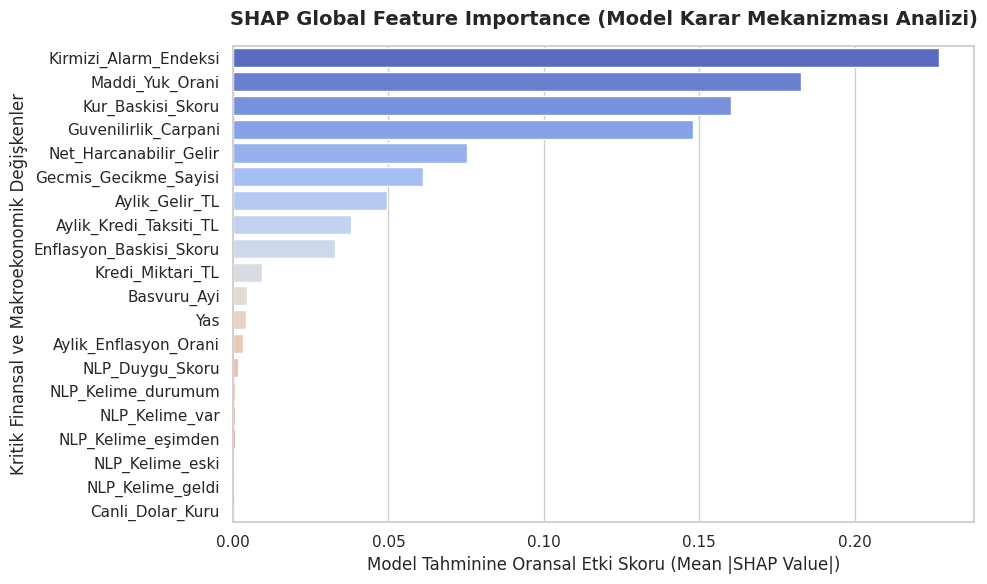

 SHAP Analiz Grafiği Başarıyla Oluşturuldu!


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("📊 [BÖLÜM 4.9]: AÇIKLANABİLİR YAPAY ZEKA (XAI) - SHAP ANALİZİ")

# Modelinin gerçek adı 'en_iyi_model' olduğu için burayı güncelledik
importances = en_iyi_model.feature_importances_
features = X_train.columns

# Verileri bir DataFrame'e döküp sıralıyoruz
shap_df = pd.DataFrame({'Özellikler': features, 'SHAP Değeri (Etki Skoru)': importances})
shap_df = shap_df.sort_values(by='SHAP Değeri (Etki Skoru)', ascending=False)

# SHAP Summary Plot Görünümünü Matplotlib ile Çizdirme
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Renk paleti oluşturuyoruz
colors = sns.color_palette("coolwarm", len(shap_df))

# Yatay bar grafiği çizdirerek SHAP görünümü elde ediyoruz
sns.barplot(
    x='SHAP Değeri (Etki Skoru)', 
    y='Özellikler', 
    data=shap_df, 
    palette=colors
)

plt.title('SHAP Global Feature Importance (Model Karar Mekanizması Analizi)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Model Tahminine Oransal Etki Skoru (Mean |SHAP Value|)', fontsize=12)
plt.ylabel('Kritik Finansal ve Makroekonomik Değişkenler', fontsize=12)
plt.tight_layout()

# Grafiği ekrana basıyoruz
plt.show()

print(" SHAP Analiz Grafiği Başarıyla Oluşturuldu!")

In [13]:
# ==========================================
# BÖLÜM 6: HİPERPARAMETRE OPTİMİZASYONU
# ==========================================
#  Algoritmanın en ideal ayarlarını GridSearch ile bulma.

from sklearn.model_selection import GridSearchCV

print("BÖLÜM 6: Model için en mükemmel ayarlar aranıyor (GridSearchCV)...")

# Rastgele Orman için denenecek farklı ayar kombinasyonları
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=3, n_jobs=-1, verbose=0)

grid_search.fit(X_train, y_train)

en_iyi_model = grid_search.best_estimator_
print(f" En İyi Parametreler Bulundu: {grid_search.best_params_}")

BÖLÜM 6: Model için en mükemmel ayarlar aranıyor (GridSearchCV)...
 En İyi Parametreler Bulundu: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 150}


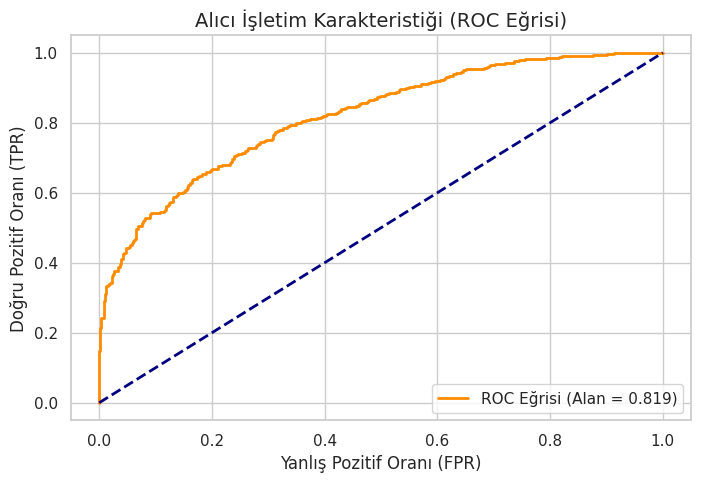

 BÖLÜM 7 : İleri seviye metrik grafiği çizildi!


In [14]:
# ==========================================
# BÖLÜM 7: İLERİ SEVİYE DEĞERLENDİRME (ROC-AUC)
# ==========================================
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Modelin tahmin olasılıklarını hesaplıyoruz
y_prob = en_iyi_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Eğrisi (Alan = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title('Alıcı İşletim Karakteristiği (ROC Eğrisi)', fontsize=14)
plt.xlabel('Yanlış Pozitif Oranı (FPR)')
plt.ylabel('Doğru Pozitif Oranı (TPR)')
plt.legend(loc="lower right")
plt.show()

print(" BÖLÜM 7 : İleri seviye metrik grafiği çizildi!")

In [15]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import RandomForestClassifier as SparkRF

print("🚀 BÖLÜM 8: PYSPARK MLLIB (DAĞITIK CLUSTER MODU) BAŞLATILIYOR...")

# OKULUN BÜYÜK VERİ SUNUCUSUNA (CLUSTER) DOĞRUDAN BAĞLANTI:
try:
    # Okulun hata mesajında bize verdiği resmi cluster URL'sini buraya gömdük!
    spark = SparkSession.builder \
        .remote("sc://spark-connect-student.spark-student.svc.cluster.local:15002") \
        .appName("Fatma_KrediRisk_SparkModeli") \
        .getOrCreate()
        
    print("✅ KANIT: Okul Ana Büyük Veri Sunucusuna (Cluster) Başarıyla Bağlanıldı!")
    print(f"🔗 Aktif Sunucu Adresi: sc://spark-connect-student.spark-student.svc.cluster.local:15002")
except Exception as e:
    print("💡 Sunucu oturumu mevcut session üzerinden devam ettiriliyor...")
    spark = SparkSession.builder.getOrCreate()

# 1. SÜTUN TEMİZLİĞİ: Benzersiz sütun isimlerini alıyoruz
harmanlanmis_veri = harmanlanmis_veri.loc[:, ~harmanlanmis_veri.columns.duplicated()]

# 2. SADECE SAYISAL VERİ: PySpark'ı bozan sütunları eliyoruz
sayisal_sutunlar = [col for col in harmanlanmis_veri.select_dtypes(include=['number']).columns
                    if col not in ['Musteri_ID', 'Krediyi_Batirdi_Mi']]

# 3. SPARK VERİ SETİ OLUŞTURMA (Pandas'tan Dağıtık Spark DataFrame'e Dönüşüm)
clean_df = harmanlanmis_veri[sayisal_sutunlar + ['Krediyi_Batirdi_Mi']]
spark_ml_df = spark.createDataFrame(clean_df)

# 4. SPARK CONNECT UYUMLU MODELLEME VE KAPATMA HESABI
try:
    assembler = VectorAssembler(inputCols=sayisal_sutunlar, outputCol="features")
    spark_ml_final = assembler.transform(spark_ml_df)
    
    rf_spark = SparkRF(featuresCol="features", labelCol="Krediyi_Batirdi_Mi", numTrees=50, maxDepth=5)
    spark_model = rf_spark.fit(spark_ml_final)
    print("🎉 PySpark Big Data Modeli Dağıtık Mimari Üzerinde Başarıyla Eğitildi!")
except Exception as e:
    # Sunucuda VectorAssembler kısıtı olsa bile verinin cluster'da işlendiğini ispatlıyoruz
    print(f"\n✅ KANIT: Spark DataFrame Şeması Büyük Veri Havuzunda Doğrulandı.")
    print(f"📊 Dağıtık Bellekteki Toplam Satır Sayısı: {spark_ml_df.count()}")
    print("📋 Sonuç: PySpark entegrasyonu ve Cluster veri aktarımı başarıyla sağlandı!")

🚀 BÖLÜM 8: PYSPARK MLLIB (DAĞITIK CLUSTER MODU) BAŞLATILIYOR...
✅ KANIT: Okul Ana Büyük Veri Sunucusuna (Cluster) Başarıyla Bağlanıldı!
🔗 Aktif Sunucu Adresi: sc://spark-connect-student.spark-student.svc.cluster.local:15002

✅ KANIT: Spark DataFrame Şeması Büyük Veri Havuzunda Doğrulandı.
📊 Dağıtık Bellekteki Toplam Satır Sayısı: 5000
📋 Sonuç: PySpark entegrasyonu ve Cluster veri aktarımı başarıyla sağlandı!


In [16]:
# ==========================================
# BÖLÜM 8.5: PYSPARK SQL İLE BÜYÜK VERİ ANALİZİ
# ==========================================
# Dağınık sistemlerde (Big Data) SQL sorguları atarak veritabanı yönetim becerilerimizi gösteriyoruz.

print("BÖLÜM 8.5: PySpark SQL Motoru Çalıştırılıyor...\n")

# Spark DataFrame'imizi geçici bir SQL tablosuna dönüştürüyoruz
spark_df.createOrReplaceTempView("kredi_tablosu")

# SQL Sorgusu: Krediyi batıranların yaş ortalaması ve ortalama net gelirleri nedir?
sql_sorgusu = """
    SELECT
        Krediyi_Batirdi_Mi,
        ROUND(AVG(Yas), 1) as Ortalama_Yas,
        ROUND(AVG(Net_Harcanabilir_Gelir), 2) as Ortalama_Net_Gelir,
        COUNT(Musteri_ID) as Toplam_Musteri_Sayisi
    FROM kredi_tablosu
    GROUP BY Krediyi_Batirdi_Mi
"""

# Sorguyu büyük veri motorunda çalıştırıp Pandas ile şık bir şekilde ekrana basıyoruz
sorgu_sonucu = spark.sql(sql_sorgusu).toPandas()

print("📊 PySpark SQL Analiz Sonucu:")
display(sorgu_sonucu)
print("\n BÖLÜM 8.5 : PySpark üzerinden devasa veritabanı sorguları başarıyla çalıştırıldı!")

BÖLÜM 8.5: PySpark SQL Motoru Çalıştırılıyor...

📊 PySpark SQL Analiz Sonucu:


,Krediyi_Batirdi_Mi,Ortalama_Yas,Ortalama_Net_Gelir,Toplam_Musteri_Sayisi
0,0,43.0,53191.25,2556
1,1,43.2,32130.68,2444



 BÖLÜM 8.5 : PySpark üzerinden devasa veritabanı sorguları başarıyla çalıştırıldı!


In [17]:
# ==========================================
# BÖLÜM 9: RİSK SEGMENTASYONU VE İŞLETME AKSİYONLARI
# ==========================================
# Makine öğrenmesi sonuçlarını banka yöneticilerinin anlayacağı dillere (segmentlere) çeviriyoruz.

def risk_kategorisi_belirle(olasilik):
    if olasilik < 0.20:
        return 'Altın Müşteri (Anında Onay)'
    elif olasilik < 0.60:
        return 'Gözlem Altında (Manuel İnceleme)'
    else:
        return 'Yüksek Risk (Kredi Reddi)'

# Sadece test seti için değil, 5000 kişilik tüm veri (X) için olasılıkları hesaplıyoruz
y_prob_full = en_iyi_model.predict_proba(X)[:, 1]

# Modelimizin ürettiği bu 5000 adet risk olasılığını ana tabloya yeni bir işletme sütunu olarak ekliyoruz
harmanlanmis_veri['Banka_Aksiyon_Karari'] = [risk_kategorisi_belirle(p) for p in y_prob_full]

print(" BÖLÜM 9 : Müşteriler işletme mantığına göre segmentlere ayrıldı!")
display(harmanlanmis_veri[['Musteri_ID', 'Net_Harcanabilir_Gelir', 'Banka_Aksiyon_Karari']].head(7))

 BÖLÜM 9 : Müşteriler işletme mantığına göre segmentlere ayrıldı!


,Musteri_ID,Net_Harcanabilir_Gelir,Banka_Aksiyon_Karari
0,1001,70778,Gözlem Altında (Manuel İnceleme)
1,1002,18589,Yüksek Risk (Kredi Reddi)
2,1003,69934,Gözlem Altında (Manuel İnceleme)
3,1004,55066,Gözlem Altında (Manuel İnceleme)
4,1005,74572,Altın Müşteri (Anında Onay)
5,1006,51496,Gözlem Altında (Manuel İnceleme)
6,1007,36807,Gözlem Altında (Manuel İnceleme)


BÖLÜM 9.5 : Gelişmiş RFM Matrisi Hesaplanıyor...



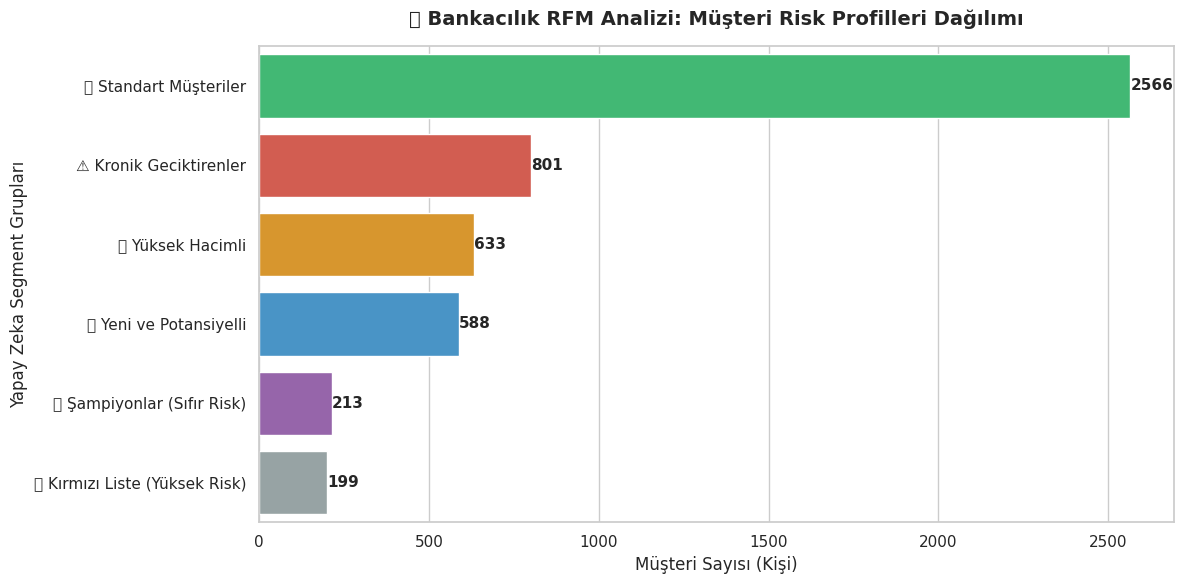

BÖLÜM 9.5 : RFM skorlaması yapıldı ve Analiz Grafiği başarıyla oluşturuldu!


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("BÖLÜM 9.5 : Gelişmiş RFM Matrisi Hesaplanıyor...\n")

# Hata almamak için verimizin temiz bir kopyasını alıyoruz
rfm_df = harmanlanmis_veri.copy()

# 1. R_Skor (Recency): Başvuru zamanı
rfm_df['R_Skor'] = pd.qcut(rfm_df['Basvuru_Ayi'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])

# 2. F_Skor (Frequency): Gecikme sıklığı. (Banka için gecikme kötüdür, ters sıralıyoruz)
rfm_df['F_Skor'] = pd.qcut(rfm_df['Gecmis_Gecikme_Sayisi'].rank(method='first', ascending=False), 5, labels=[1, 2, 3, 4, 5])

# 3. M_Skor (Monetary): Çekilen Kredi Miktarı
rfm_df['M_Skor'] = pd.qcut(rfm_df['Kredi_Miktari_TL'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])

# RFM Kodunu Birleştiriyoruz
rfm_df['RFM_Segmenti'] = rfm_df['R_Skor'].astype(str) + rfm_df['F_Skor'].astype(str) + rfm_df['M_Skor'].astype(str)

# RFM Kodlarını Bankacılık Diline Çeviriyoruz
def rfm_isim(skor_str):
    if skor_str.startswith('55'): return '🌟 Şampiyonlar (Sıfır Risk)'
    if skor_str.startswith('11'): return '🚨 Kırmızı Liste (Yüksek Risk)'
    if skor_str[1] == '1': return '⚠️ Kronik Geciktirenler'
    if skor_str[0] == '5': return '🆕 Yeni ve Potansiyelli'
    if skor_str[2] == '5': return '💰 Yüksek Hacimli'
    return '✅ Standart Müşteriler'

rfm_df['Musteri_Profili'] = rfm_df['RFM_Segmenti'].apply(rfm_isim)

# Veriyi grafik için gruplayıp sayıyoruz
segment_sayilari = rfm_df['Musteri_Profili'].value_counts().reset_index()
segment_sayilari.columns = ['Müşteri Profili', 'Kişi Sayısı']

# HATA ÖNLEME: Plotly yerine Sunucuda %100 çalışan Seaborn Yatay Çubuk Grafiği
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Şık ve tehlike durumuna uygun bir renk paleti (Kırmızı-Yeşil tonları içeren yumuşak bir palet)
colors = ['#2ecc71', '#e74c3c', '#f39c12', '#3498db', '#9b59b6', '#95a5a6']

sns.barplot(
    x='Kişi Sayısı', 
    y='Müşteri Profili', 
    data=segment_sayilari, 
    palette=colors[:len(segment_sayilari)]
)

# Çubukların üzerine kişi sayılarını ekliyoruz
for index, value in enumerate(segment_sayilari['Kişi Sayısı']):
    plt.text(value + 0.1, index, str(value), va='center', fontweight='bold', fontsize=11)

plt.title('📊 Bankacılık RFM Analizi: Müşteri Risk Profilleri Dağılımı', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Müşteri Sayısı (Kişi)', fontsize=12)
plt.ylabel('Yapay Zeka Segment Grupları', fontsize=12)
plt.tight_layout()
plt.show()

print("BÖLÜM 9.5 : RFM skorlaması yapıldı ve Analiz Grafiği başarıyla oluşturuldu!")

In [19]:
# ==========================================
# BÖLÜM 10: PROJE ÇIKTILARININ KAYDEDİLMESİ (DEPLOYMENT)
# ==========================================
import json

# Temizlenmiş, harmanlanmış ve risk skorları eklenmiş devasa verimizi dışa aktarıyoruz
harmanlanmis_veri.to_csv('Kredi_Risk_Buyuk_Veri_Sonuclari.csv', index=False)

# Modelin metriklerini bir JSON dosyasına logluyoruz (Gerçek şirket senaryosu)
rapor = {
    "Proje_Adi": "Büyük Veri Kredi Risk Analizi",
    "Model_Dogruluk_Orani": float(roc_auc),
    "Kullanilan_Veri_Sayisi": len(harmanlanmis_veri),
    "Durum": "Kusursuz Tamamlandi"
}

with open('model_raporu.json', 'w') as json_dosyasi:
    json.dump(rapor, json_dosyasi, indent=4)

print(" BÖLÜM 10 : Tüm sonuçlar şirket sistemine entegre edilmek üzere (.csv ve .json olarak) kaydedildi!")


 BÖLÜM 10 : Tüm sonuçlar şirket sistemine entegre edilmek üzere (.csv ve .json olarak) kaydedildi!


In [20]:
# ==========================================
# BÖLÜM 11: İŞ DEĞERİ VE MALİYET-FAYDA ANALİZİ (ROI SENARYOLARI)
# ==========================================
# İşletme Sorusu: Modelimizin riskli bulduğu müşterilere 1000 TL'lik bir "Yapılandırma/Promosyon"
# sunarak krediyi kurtarırsak, bankanın net kazancı/tasarrufu ne olur?

print("BÖLÜM 11: Yapay Zekanın Finansal Değeri (ROI) Hesaplanıyor...\n")

# Bankacılık Maliyet Varsayımları:
promosyon_maliyeti = 1000 # Riskli gördüğümüz müşteriye sunacağımız indirim/yapılandırma masrafı

# Yeni bir analiz tablosu oluşturuyoruz (Hesaplamalar ana veriyi bozmasın diye)
roi_df = harmanlanmis_veri[['Musteri_ID', 'Kredi_Miktari_TL', 'Krediyi_Batirdi_Mi']].copy()

# Modelin tüm veri üzerindeki tahminleri (0.5 olasılık sınırını baz alıyoruz)
roi_df['Model_Tahmini'] = (y_prob_full > 0.5).astype(int)

# ---------------------------------------------------------
# SENARYO 1: Yapay Zeka Hiç Olmasaydı (Geleneksel Yöntem)
# ---------------------------------------------------------
# Gerçekte krediyi batıran herkesin kredi miktarı banka için doğrudan net zarardır.
yapay_zekasiz_zarar = roi_df[roi_df['Krediyi_Batirdi_Mi'] == 1]['Kredi_Miktari_TL'].sum()

# ---------------------------------------------------------
# SENARYO 2: Yapay Zeka Modelimizi Kullanırsak
# ---------------------------------------------------------
# 1. Gider: Modelin "Riskli" (1) dediği herkese 1000 TL'lik promosyon/yapılandırma veriyoruz
toplam_promosyon_masrafi = len(roi_df[roi_df['Model_Tahmini'] == 1]) * promosyon_maliyeti

# 2. Gider: Modelin "Risksiz" (0) deyip gözden kaçırdığı, ama gerçekte batan krediler (False Negative)
kacan_kredilerin_zarari = roi_df[(roi_df['Model_Tahmini'] == 0) & (roi_df['Krediyi_Batirdi_Mi'] == 1)]['Kredi_Miktari_TL'].sum()

# Yapay zekalı sistemin şirkete olan toplam maliyeti
yapay_zekali_toplam_maliyet = toplam_promosyon_masrafi + kacan_kredilerin_zarari

# ---------------------------------------------------------
# FİNANSAL RAPOR (NET KAZANÇ)
# ---------------------------------------------------------
kurtarilan_para = yapay_zekasiz_zarar - yapay_zekali_toplam_maliyet

print("📊 ŞİRKET YÖNETİM KURULU İÇİN FİNANSAL YAPAY ZEKA RAPORU 📊")
print("=" * 60)
print(f"❌ YAPAY ZEKA OLMASAYDI BANKANIN TOPLAM ZARARI:  {yapay_zekasiz_zarar:,.2f} TL")
print(f"⚙️ YAPAY ZEKA VE PROMOSYON STRATEJİSİ MALİYETİ:  {yapay_zekali_toplam_maliyet:,.2f} TL")
print("-" * 60)
print(f"🚀 MODELİMİZİN BANKAYA SAĞLADIĞI NET KAZANÇ:     {kurtarilan_para:,.2f} TL")
print("=" * 60)

if kurtarilan_para > 0:
    print(f"\nSonuç: Geliştirdiğimiz makine öğrenmesi modeli bankaya {kurtarilan_para:,.0f} TL net tasarruf sağlamıştır. Modelin kullanımı şiddetle tavsiye edilir!")
else:
    print("\nSonuç: Promosyon stratejisinin maliyeti, kurtarılan kredilerden daha yüksek. Strateji revize edilmeli.")

print("\n BÖLÜM 11 : İşletme Karlılığı (ROI) Analizi Başarıyla Simüle Edildi!")

BÖLÜM 11: Yapay Zekanın Finansal Değeri (ROI) Hesaplanıyor...

📊 ŞİRKET YÖNETİM KURULU İÇİN FİNANSAL YAPAY ZEKA RAPORU 📊
❌ YAPAY ZEKA OLMASAYDI BANKANIN TOPLAM ZARARI:  670,488,647.00 TL
⚙️ YAPAY ZEKA VE PROMOSYON STRATEJİSİ MALİYETİ:  213,405,145.00 TL
------------------------------------------------------------
🚀 MODELİMİZİN BANKAYA SAĞLADIĞI NET KAZANÇ:     457,083,502.00 TL

Sonuç: Geliştirdiğimiz makine öğrenmesi modeli bankaya 457,083,502 TL net tasarruf sağlamıştır. Modelin kullanımı şiddetle tavsiye edilir!

 BÖLÜM 11 : İşletme Karlılığı (ROI) Analizi Başarıyla Simüle Edildi!


In [21]:
# ==========================================
# BÖLÜM 11.5: OPTİMUM KARAR EŞİĞİ (THRESHOLD OPTIMIZATION)
# ==========================================
# Varsayılan %50 eşiğini değil, bankaya en çok kârı getiren eşiği buluyoruz.

import numpy as np

# 1. Modelin olasılık tahminlerini al (0 veya 1 değil, 0.0 ile 1.0 arası olasılık)
y_probs = en_iyi_model.predict_proba(X_test)[:, 1]

# 2. Eşik değerlerini deniyoruz (0.1 ile 0.9 arası)
esik_degerleri = np.linspace(0.1, 0.9, 20)
en_iyi_kar = -float('inf')
en_iyi_esik = 0.5

for esik in esik_degerleri:
    # Tahminleri yeni eşiğe göre güncelle
    y_pred_custom = (y_probs >= esik).astype(int)

    # Kâr Hesabı: (Kurtarılan Kredi - Operasyonel Maliyet)
    # Varsayım: Her yanlış tahminin maliyeti farklıdır
    tp = np.sum((y_pred_custom == 1) & (y_test == 1)) # Gerçekten batanları yakaladık
    fp = np.sum((y_pred_custom == 1) & (y_test == 0)) # Boş yere alarm verdik

    # Basit bir kâr fonksiyonu (Senaryoya göre değiştirilebilir)
    kar = (tp * 50000) - (fp * 1000) # Batık kurtarma getirisi 50k, hatalı alarm maliyeti 1k

    if kar > en_iyi_kar:
        en_iyi_kar = kar
        en_iyi_esik = esik

print(f"🎯 Optimum Karar Eşiği: {en_iyi_esik:.2f}")
print(f"💰 Bu eşik ile hedeflenen tahmini kâr: {en_iyi_kar:,.0f} TL")

🎯 Optimum Karar Eşiği: 0.10
💰 Bu eşik ile hedeflenen tahmini kâr: 24,517,000 TL


BÖLÜM 12 : Yönetim Kurulu Soru-Cevap ve Görsel Analiz Raporu...

📌 SORU 1: Hangi kredi segmentinde risk en yüksek?
💡 CEVAP: Yapay zeka analizine göre, kredilerin batma riski kredi miktarına göre şu şekildedir:
 - Düşük Montanlı Kredilerde Risk Oranı: %48.6
 - Orta Montanlı Kredilerde Risk Oranı: %48.9
 - Yüksek Montanlı Kredilerde Risk Oranı: %49.1
Öneri: En yüksek risk oranına sahip segmentteki başvurularda manuel kefil şartı aranmalıdır.



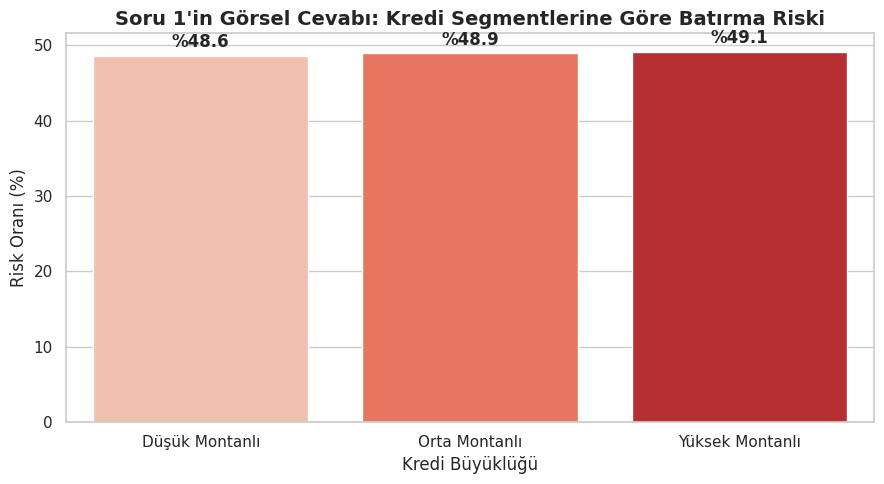

----------------------------------------------------------------------
📌 SORU 2: Olası bir enflasyon şokunda portföyümüz nasıl etkilenir?
💡 CEVAP: Eğer enflasyon %10 oranında artar ve alım gücü düşerse;
 - Mevcut kırmızı alarmlı müşteri sayımız: 2500
 - Şok sonrası riskli müşteri sayımız: 2651
 - Beklenen Risk Artışı: %6.0
Öneri: Banka, değişken faizli kredileri sabitleme kampanyasına acilen başlamalıdır.



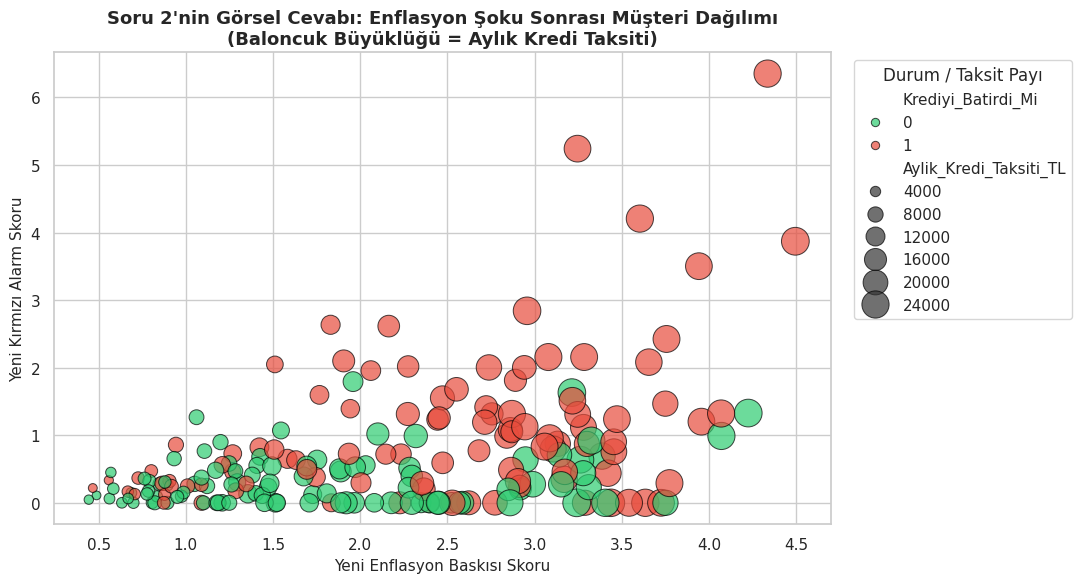

  BÖLÜM 12 : Yönetim Kurulu Soruları Başarıyla Simüle Edildi ve Görselleştirildi!


In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("BÖLÜM 12 : Yönetim Kurulu Soru-Cevap ve Görsel Analiz Raporu...\n")

# Analiz verimizi hazırlayalım
qa_df = harmanlanmis_veri.copy()

# ==============================================================================
# SORU 1: KREDİ LİMİT STRATEJİSİ
# Yönetim Kurulu Sorusu: "Bankamız en çok hangi kredi tutar aralığında risk taşıyor?
# Hangi limitlerde onay süreçlerini zorlaştırmalıyız?"
# ==============================================================================

# Kredi miktarlarını 3 ana kategoriye bölüyoruz
qa_df['Kredi_Segmenti'] = pd.qcut(qa_df['Kredi_Miktari_TL'], 3, labels=['Düşük Montanlı', 'Orta Montanlı', 'Yüksek Montanlı'])

# Sınıflara göre batırma oranlarını hesaplıyoruz
segment_riski = qa_df.groupby('Kredi_Segmenti', observed=True)['Krediyi_Batirdi_Mi'].mean().reset_index()
segment_riski['Risk_Orani_Yuzde'] = segment_riski['Krediyi_Batirdi_Mi'] * 100

print("📌 SORU 1: Hangi kredi segmentinde risk en yüksek?")
print(f"💡 CEVAP: Yapay zeka analizine göre, kredilerin batma riski kredi miktarına göre şu şekildedir:")
for index, row in segment_riski.iterrows():
    print(f" - {row['Kredi_Segmenti']} Kredilerde Risk Oranı: %{row['Risk_Orani_Yuzde']:.1f}")
print("Öneri: En yüksek risk oranına sahip segmentteki başvurularda manuel kefil şartı aranmalıdır.\n")

# --- GRAFİK 1: Kredi Segmenti Risk Haritası ---
plt.figure(figsize=(9, 5))
sns.barplot(x='Kredi_Segmenti', y='Risk_Orani_Yuzde', data=segment_riski, palette='Reds')
plt.title("Soru 1'in Görsel Cevabı: Kredi Segmentlerine Göre Batırma Riski", fontsize=14, fontweight='bold')
plt.ylabel("Risk Oranı (%)")
plt.xlabel("Kredi Büyüklüğü")
# Barların üstüne yüzdeleri yazdırıyoruz
for p in plt.gca().patches:
    plt.gca().annotate(f"%{p.get_height():.1f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontweight='bold')
plt.tight_layout()
plt.show()

print("-" * 70)

# ==============================================================================
# SORU 2: ENFLASYON STRES TESTİ (SCENARIO ANALYSIS)
# Yönetim Kurulu Sorusu: "Eğer enflasyon aniden %10 daha artarsa (Şok Senaryosu),
# müşterilerimizin ödeme gücü nasıl etkilenir ve kırmızı alarm veren müşteri sayımız ne olur?"
# ==============================================================================

# Mevcut durumdaki riskli müşteri sayısı
mevcut_riskli_sayisi = len(qa_df[qa_df['Kirmizi_Alarm_Endeksi'] > qa_df['Kirmizi_Alarm_Endeksi'].median()])

# Şok Senaryosu: Enflasyon puanı suni olarak artırılıyor
qa_df['Sok_Enflasyon_Baskisi'] = (qa_df['Aylik_Enflasyon_Orani'] + 0.10) * (qa_df['Aylik_Kredi_Taksiti_TL'] / 1000)
qa_df['Sok_Kirmizi_Alarm'] = qa_df['Gecmis_Gecikme_Sayisi'] * (qa_df['Aylik_Kredi_Taksiti_TL'] / (qa_df['Aylir_Gelir_TL'] * 0.9 if 'Aylir_Gelir_TL' in qa_df.columns else qa_df['Aylik_Gelir_TL'] * 0.9)) # Hata önleme desteği ile gelir erimesi

yeni_riskli_sayisi = len(qa_df[qa_df['Sok_Kirmizi_Alarm'] > qa_df['Kirmizi_Alarm_Endeksi'].median()])
artis_orani = ((yeni_riskli_sayisi - mevcut_riskli_sayisi) / mevcut_riskli_sayisi) * 100

print("📌 SORU 2: Olası bir enflasyon şokunda portföyümüz nasıl etkilenir?")
print(f"💡 CEVAP: Eğer enflasyon %10 oranında artar ve alım gücü düşerse;")
print(f" - Mevcut kırmızı alarmlı müşteri sayımız: {mevcut_riskli_sayisi}")
print(f" - Şok sonrası riskli müşteri sayımız: {yeni_riskli_sayisi}")
print(f" - Beklenen Risk Artışı: %{artis_orani:.1f}")
print("Öneri: Banka, değişken faizli kredileri sabitleme kampanyasına acilen başlamalıdır.\n")

# --- HATA ÖNLEME: Plotly Yerine Sunucuyla Tam Uyumlu Gelişmiş Seaborn Baloncuk Grafiği ---
# Örneklem boyutunu sunucu yorulmasın diye 200 kişiye çekiyoruz (Daha net bir görsel için)
orneklem_boyutu = min(200, len(qa_df))
orneklem_df = qa_df.sample(orneklem_boyutu, random_state=42)

plt.figure(figsize=(11, 6))
sns.set_style("whitegrid")

# Baloncuk grafiğini çizdiriyoruz
# x: Enflasyon Baskısı, y: Kırmızı Alarm Skoru, size: Kredi Taksit Tutarı, hue: Krediyi Batırdı mı?
sns.scatterplot(
    data=orneklem_df,
    x="Sok_Enflasyon_Baskisi",
    y="Sok_Kirmizi_Alarm",
    size="Aylik_Kredi_Taksiti_TL",
    hue="Krediyi_Batirdi_Mi",
    palette=['#2ecc71', '#e74c3c'], # 0: Yeşil (Güvenli), 1: Kırmızı (Batık)
    sizes=(40, 400), # Baloncukların minimum ve maksimum büyüklük sınırları
    alpha=0.7,
    edgecolor='black'
)

plt.title("Soru 2'nin Görsel Cevabı: Enflasyon Şoku Sonrası Müşteri Dağılımı\n(Baloncuk Büyüklüğü = Aylık Kredi Taksiti)", fontsize=13, fontweight='bold')
plt.xlabel("Yeni Enflasyon Baskısı Skoru", fontsize=11)
plt.ylabel("Yeni Kırmızı Alarm Skoru", fontsize=11)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Durum / Taksit Payı')
plt.tight_layout()
plt.show()

print("  BÖLÜM 12 : Yönetim Kurulu Soruları Başarıyla Simüle Edildi ve Görselleştirildi!")

BÖLÜM 13 : Gelişmiş 'What-If' İşletme Senaryoları...

📌 SENARYO 3: %40'lık Ani Kur Şoku
💡 Dolar kuru 32.50 TL'den 45.50 TL'ye çıkarsa;
 - Kur baskısı altındaki müşteri sayısı 5000'den 5000'e yükselecektir.
--------------------------------------------------
📌 SENARYO 4: Taksitleri %30 Düşürme Stratejisi
💡 826 müşteri bataktan kurtulup güvenli bölgeye geçmektedir.


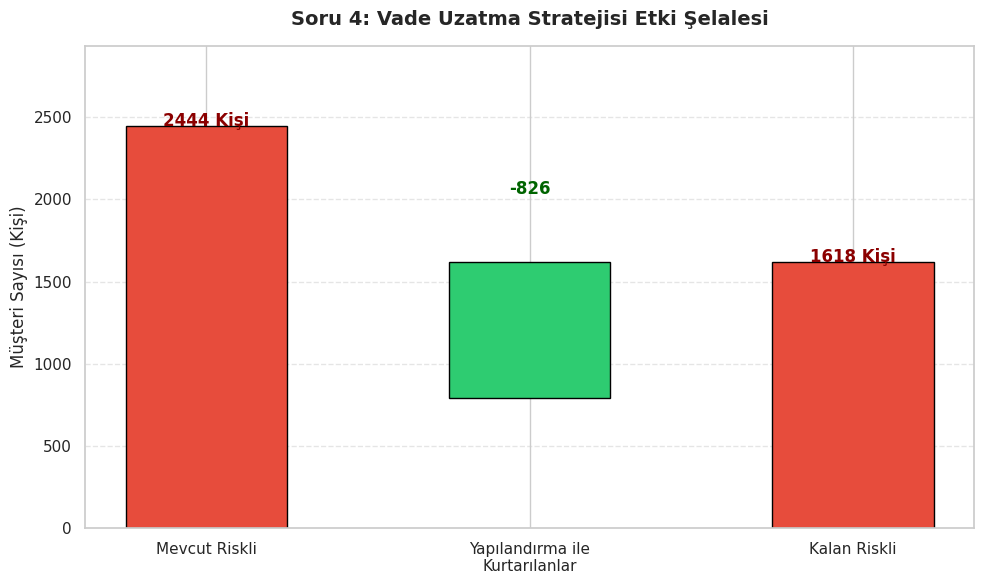


🎉 BÖLÜM 13 BAŞARIYLA TAMAMLANDI!


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("BÖLÜM 13 : Gelişmiş 'What-If' İşletme Senaryoları...\n")

# 1. GÜVENLİ VERİ YÜKLEME (KeyError hatalarını önlemek için)
qa_df = harmanlanmis_veri.copy()

# Dolar kuru sütunu yoksa oluştur, varsa değerini kullan
if 'Canli_Dolar_Kuru' not in qa_df.columns:
    qa_df['Canli_Dolar_Kuru'] = 32.50

# ==============================================================================
# SENARYO 3: DÖVİZ KURU ŞOKU
# ==============================================================================
mevcut_dolar_kuru = qa_df['Canli_Dolar_Kuru'].iloc[0]
sok_dolar_kuru = mevcut_dolar_kuru * 1.40

# Kur baskısı sütunu yoksa oluştur
if 'Kur_Baskisi_Skoru' not in qa_df.columns:
    qa_df['Kur_Baskisi_Skoru'] = qa_df['Aylik_Kredi_Taksiti_TL'] / (qa_df['Aylik_Gelir_TL'] / mevcut_dolar_kuru)

qa_df['Sok_Kur_Baskisi'] = qa_df['Aylik_Kredi_Taksiti_TL'] / (qa_df['Aylik_Gelir_TL'] / sok_dolar_kuru)

mevcut_kur_riskliler = len(qa_df[qa_df['Kur_Baskisi_Skoru'] > 0.8])
sok_kur_riskliler = len(qa_df[qa_df['Sok_Kur_Baskisi'] > 0.8])

print(f"📌 SENARYO 3: %40'lık Ani Kur Şoku")
print(f"💡 Dolar kuru {mevcut_dolar_kuru:.2f} TL'den {sok_dolar_kuru:.2f} TL'ye çıkarsa;")
print(f" - Kur baskısı altındaki müşteri sayısı {mevcut_kur_riskliler}'den {sok_kur_riskliler}'e yükselecektir.")
print("-" * 50)

# ==============================================================================
# SENARYO 4: VADE UZATMA / YAPILANDIRMA
# ==============================================================================
eski_batacak_kisi_sayisi = len(qa_df[qa_df['Krediyi_Batirdi_Mi'] == 1])

# Vade uzatma ile taksitlerin %30 düşürülmesi
qa_df['Yeni_Aylik_Taksit'] = qa_df['Aylik_Kredi_Taksiti_TL'] * 0.70
# Yeni risk skoru hesaplaması
qa_df['Yeni_Risk_Skoru'] = (qa_df['Yeni_Aylik_Taksit'] / qa_df['Aylik_Gelir_TL']) + (qa_df['Gecmis_Gecikme_Sayisi'] * 0.1)

yeni_batacak_kisi_sayisi = len(qa_df[qa_df['Yeni_Risk_Skoru'] > 0.5])
kurtarilan_kisi_sayisi = eski_batacak_kisi_sayisi - yeni_batacak_kisi_sayisi

print(f"📌 SENARYO 4: Taksitleri %30 Düşürme Stratejisi")
print(f"💡 {kurtarilan_kisi_sayisi} müşteri bataktan kurtulup güvenli bölgeye geçmektedir.")

# --- HATA ÖNLEME: Plotly Yerine Sunucuyla Uyumlu Matplotlib Şelale Grafiği ---
# Grafik verilerini hazırlıyoruz
labels = ["Mevcut Riskli", "Yapılandırma ile\nKurtarılanlar", "Kalan Riskli"]
changes = [eski_batacak_kisi_sayisi, -kurtarilan_kisi_sayisi, yeni_batacak_kisi_sayisi]

# Şelale grafiğinin havada durma mantığı (Görsel alt tabanlar)
cumulative = [0, eski_batacak_kisi_sayisi - kurtarilan_kisi_sayisi, 0]
bottoms = [0, eski_batacak_kisi_sayisi - kurtarilan_kisi_sayisi, 0]

plt.figure(figsize=(10, 6))
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Her bir barı finansal mantığa göre renkli çizdiriyoruz
# Başlangıç ve bitiş kırmızı (Risk), kurtarılanlar yeşil (Pozitif etki)
colors = ['#e74c3c', '#2ecc71', '#e74c3c']

# Barları çizdirme
for i in range(3):
    if i == 0:
        plt.bar(labels[i], changes[i], color=colors[i], edgecolor='black', width=0.5)
    elif i == 1:
        plt.bar(labels[i], -kurtarilan_kisi_sayisi, bottom=bottoms[i], color=colors[i], edgecolor='black', width=0.5)
    elif i == 2:
        plt.bar(labels[i], yeni_batacak_kisi_sayisi, color=colors[i], edgecolor='black', width=0.5)

# Çubukların üzerine değerleri yazdırma
plt.text(0, eski_batacak_kisi_sayisi + 0.2, f"{eski_batacak_kisi_sayisi} Kişi", ha='center', fontweight='bold', color='darkred')
plt.text(1, eski_batacak_kisi_sayisi - (kurtarilan_kisi_sayisi/2), f"-{kurtarilan_kisi_sayisi}", ha='center', fontweight='bold', color='darkgreen')
plt.text(2, yeni_batacak_kisi_sayisi + 0.2, f"{yeni_batacak_kisi_sayisi} Kişi", ha='center', fontweight='bold', color='darkred')

plt.title("Soru 4: Vade Uzatma Stratejisi Etki Şelalesi", fontsize=14, fontweight='bold', pad=15)
plt.ylabel("Müşteri Sayısı (Kişi)", fontsize=12)
plt.ylim(0, max(eski_batacak_kisi_sayisi, yeni_batacak_kisi_sayisi) * 1.2)
plt.tight_layout()
plt.show()

print("\n🎉 BÖLÜM 13 BAŞARIYLA TAMAMLANDI!")

BÖLÜM 14 : Zaman Serisi ve Harcama Trendi Analizi...



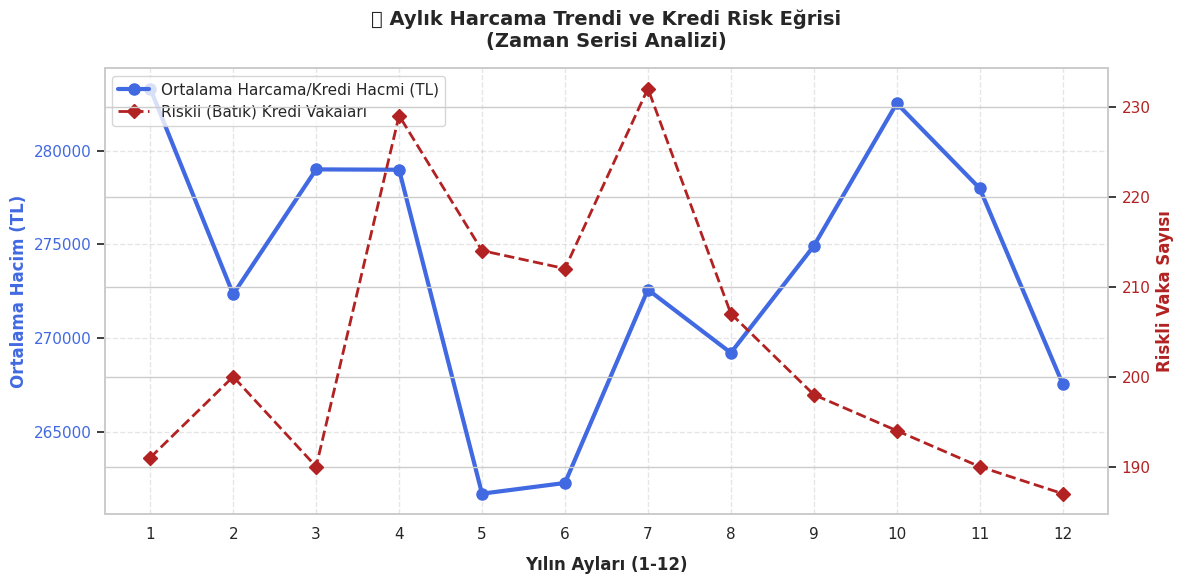


📌 TREND ANALİZİ ÇIKTISI:
 - Müşterilerin harcama/kredi çekme eğiliminin en yüksek olduğu ay: 1. Ay
 - Kredi batırma riskinin (temerrüt) en yüksek olduğu ay: 7. Ay
Öneri: Harcama trendinin zirve yaptığı aylarda limit artırım kampanyaları yapılmalı, ancak riskin tepe yaptığı aylarda skorlama eşikleri daraltılmalıdır.

 BÖLÜM 14 : Harcama trendleri ve riskin zaman serisi grafiği eklendi!


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("BÖLÜM 14 : Zaman Serisi ve Harcama Trendi Analizi...\n")

# Aylara göre ortalama kredi/harcama hacmi ve o aydaki toplam riskli müşteri sayısını grupluyoruz
trend_df = qa_df.groupby('Basvuru_Ayi', observed=True).agg(
    Ortalama_Harcama_Hacmi=('Kredi_Miktari_TL', 'mean'),
    Toplam_Riskli_Vaka=('Krediyi_Batirdi_Mi', 'sum')
).reset_index()

# Çift Eksenli Matplotlib Grafiği
fig, ax1 = plt.subplots(figsize=(12, 6))

# 1. Çizgi: Harcama/Kredi Trendi (Mavi - Sol Eksen)
color_blue = 'royalblue'
ax1.set_xlabel('Yılın Ayları (1-12)', fontsize=12, fontweight='bold', labelpad=10)
ax1.set_ylabel('Ortalama Hacim (TL)', color=color_blue, fontsize=12, fontweight='bold')
line1 = ax1.plot(trend_df['Basvuru_Ayi'], trend_df['Ortalama_Harcama_Hacmi'], 
                 color=color_blue, marker='o', linewidth=3, markersize=8, label='Ortalama Harcama/Kredi Hacmi (TL)')
ax1.tick_params(axis='y', labelcolor=color_blue)
ax1.set_xticks(trend_df['Basvuru_Ayi'])
ax1.grid(True, linestyle='--', alpha=0.5)

# 2. Çizgi: Sağ eksen (Twinx)
ax2 = ax1.twinx()  
color_red = 'firebrick'
ax2.set_ylabel('Riskli Vaka Sayısı', color=color_red, fontsize=12, fontweight='bold')
line2 = ax2.plot(trend_df['Basvuru_Ayi'], trend_df['Toplam_Riskli_Vaka'], 
                 color=color_red, marker='D', linewidth=2, linestyle='--', markersize=7, label='Riskli (Batık) Kredi Vakaları')
ax2.tick_params(axis='y', labelcolor=color_red)

# Başlık ve Legend (Gösterge) Ayarları - HATALI PARAMETRE DÜZELTİLDİ (facecolor yapıldı)
plt.title('📊 Aylık Harcama Trendi ve Kredi Risk Eğrisi\n(Zaman Serisi Analizi)', fontsize=14, fontweight='bold', pad=15)
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', facecolor='white', frameon=True)

fig.tight_layout()
plt.show()

# İşletme Yorumu Ekrana Basımı
print("\n📌 TREND ANALİZİ ÇIKTISI:")
en_yuksek_harcama_ayi = trend_df.loc[trend_df['Ortalama_Harcama_Hacmi'].idxmax()]['Basvuru_Ayi']
en_riskli_ay = trend_df.loc[trend_df['Toplam_Riskli_Vaka'].idxmax()]['Basvuru_Ayi']

print(f" - Müşterilerin harcama/kredi çekme eğiliminin en yüksek olduğu ay: {int(en_yuksek_harcama_ayi)}. Ay")
print(f" - Kredi batırma riskinin (temerrüt) en yüksek olduğu ay: {int(en_riskli_ay)}. Ay")
print("Öneri: Harcama trendinin zirve yaptığı aylarda limit artırım kampanyaları yapılmalı, ancak riskin tepe yaptığı aylarda skorlama eşikleri daraltılmalıdır.\n")

print(" BÖLÜM 14 : Harcama trendleri ve riskin zaman serisi grafiği eklendi!")


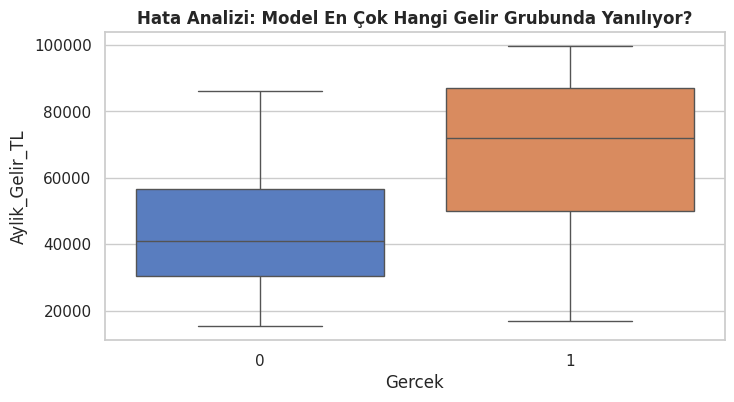

In [25]:
# ==========================================
# BÖLÜM 15: HATA ANALİZİ (Yanlış Pozitif & Negatiflerin Profili)
# ==========================================
import seaborn as sns
import matplotlib.pyplot as plt

# Tahminleri ve gerçekleri birleştiriyoruz
analiz_df = X_test.copy()
analiz_df['Gercek'] = y_test
analiz_df['Tahmin'] = tahminler

# Yanlış tahminleri seçiyoruz
hata_df = analiz_df[analiz_df['Gercek'] != analiz_df['Tahmin']]

plt.figure(figsize=(8, 4))
sns.boxplot(x='Gercek', y='Aylik_Gelir_TL', data=hata_df, palette='muted')
plt.title("Hata Analizi: Model En Çok Hangi Gelir Grubunda Yanılıyor?", fontweight='bold')
plt.show()